In [ ]:
    # AKILIMALI KALUGUSHA 
    # BAC 2 genie minier / EMI / UOB
    # TP ANALYSE ET EXPLOITATIONS DE BASE DE DONNEES

In [11]:
import numpy as np  # calcul et algebre lineaire
import pandas as pd # gestion de la base de donnees 
import matplotlib.pyplot as plt # gestion des graphes  - visualisation
import seaborn as sns # toujours pour la visualisation

Chargement de donnees

In [16]:
donnees = pd.read_csv('C:/Users/AKILIMALI KALUGUSHA/Desktop/Coffe_sales.csv', sep=',') 

In [17]:
donnees.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [ ]:
# Nombre de lignes(data points) et les nombres de colonnes(features-variables)
print('taille de la donnees: ',donnees.shape)
print('Nombre de lignes:', donnees.shape[0])
print('Nombre de colonnes:', donnees.shape[1])

taille de la donnees:  (3547, 11)
Nombre de lignes: 3547
Nombre de colonnes: 11


In [ ]:
# Informations sur les types de donnees dans nos colonnes
donnees.info()

<class 'pandas.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   str    
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   str    
 4   Time_of_Day  3547 non-null   str    
 5   Weekday      3547 non-null   str    
 6   Month_name   3547 non-null   str    
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   str    
 10  Time         3547 non-null   str    
dtypes: float64(1), int64(3), str(7)
memory usage: 304.9 KB


In [ ]:
# Verification de Valeurs manquante
donnees.isna().any()

hour_of_day    False
cash_type      False
money          False
coffee_name    False
Time_of_Day    False
Weekday        False
Month_name     False
Weekdaysort    False
Monthsort      False
Date           False
Time           False
dtype: bool

In [ ]:
# Description des valeurs numeriques: 

donnees.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [ ]:
donnees.describe().style.highlight_max(color='yellow',axis=0) # les statistique de vos donnees numerique 

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [ ]:
donnees.describe()['money']

count    3547.000000
mean       31.645216
std         4.877754
min        18.120000
25%        27.920000
50%        32.820000
75%        35.760000
max        38.700000
Name: money, dtype: float64

In [ ]:
## types de nos variables

donnees.dtypes

hour_of_day      int64
cash_type          str
money          float64
coffee_name        str
Time_of_Day        str
Weekday            str
Month_name         str
Weekdaysort      int64
Monthsort        int64
Date               str
Time               str
dtype: object

In [ ]:
# Netoyage de donnees :
donnees['house_of_day'] = donnees['house_of_day'].astype(str).str.replace(',','')
donnees['house_of_day']= donnees['house_of_day'].astype(int)

# 2 correction pour month_name
dictionnairie_mois = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}
donnees['month_name'] = donnees['month_name'].map(dictionnairie_mois)


In [ ]:
donnees['hour_of_day'].dtype

dtype('int64')

In [ ]:
# puisque 'hourse_of_day' est deja un entier (int64)
# on peut directement passer a la suite ou simplement afficher les premieres lignes pour confirmer
donnees['hour_of_day'].head()

0    10
1    12
2    12
3    13
4    13
Name: hour_of_day, dtype: int64

In [ ]:
# Analyser la distribution de prix a payes
print(donnees['money'].describe())

count    3547.000000
mean       31.645216
std         4.877754
min        18.120000
25%        27.920000
50%        32.820000
75%        35.760000
max        38.700000
Name: money, dtype: float64


In [ ]:
donnees.columns.tolist()

['hour_of_day',
 'cash_type',
 'money',
 'coffee_name',
 'Time_of_Day',
 'Weekday',
 'Month_name',
 'Weekdaysort',
 'Monthsort',
 'Date',
 'Time']

In [ ]:
# Compter le nombre de ventes pour chaque type de cafe
print(donnees['coffee_name'].value_counts())

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64


In [ ]:
donnees['money'].head()
donnees['coffee_name'].head()

0            Latte
1    Hot Chocolate
2    Hot Chocolate
3        Americano
4            Latte
Name: coffee_name, dtype: str

Visualisation

In [3]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

C:\Users\AKILIMALI KALUGUSHA\AppData\Local\Temp\ipykernel_14476\3926238747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=donnees, x='coffee_name', order=donnees['coffee_name'].value_counts().index, palette='viridis')


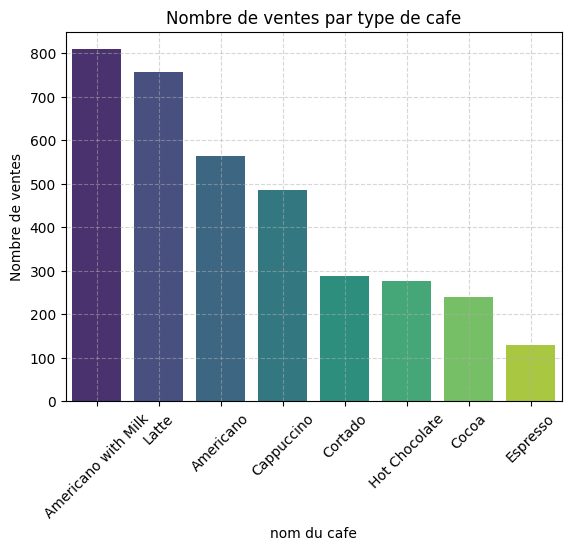

In [18]:
# On peur cree un graphique en barres avec le decompte des cafes
sns.countplot(data=donnees, x='coffee_name', order=donnees['coffee_name'].value_counts().index, palette='viridis')
plt.title('Nombre de ventes par type de cafe')
plt.xlabel('nom du cafe')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45) # rotation des etiquettes pour une meilleure lisibilite
plt.grid(True, linestyle='--', alpha=0.5) # ajoute une grille pour faciliter la lecture des valeurs
plt.show()



In [19]:
# pour les colonnes non-essentielles (n'echoue pas si la colonne n'existe pas)
donnees.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')
donnees

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


In [20]:
## sauvegarde de donnees pour une manupilation uterieure
donnees.to_csv('donnees_emiexo1.csv', index=False)

In [21]:
# compte des valeurs dans la colonne des modes paiement
donnees['cash_type'].value_counts()

cash_type
card    3547
Name: count, dtype: int64

<Axes: >

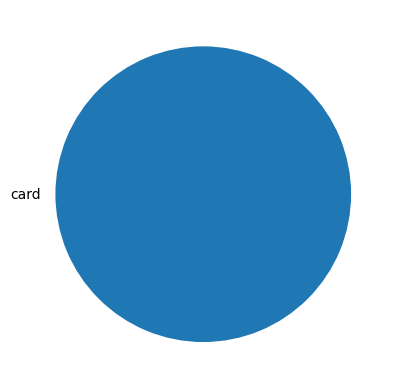

In [22]:
donnees['cash_type'].value_counts().plot(kind='pie')

<Axes: xlabel='cash_type'>

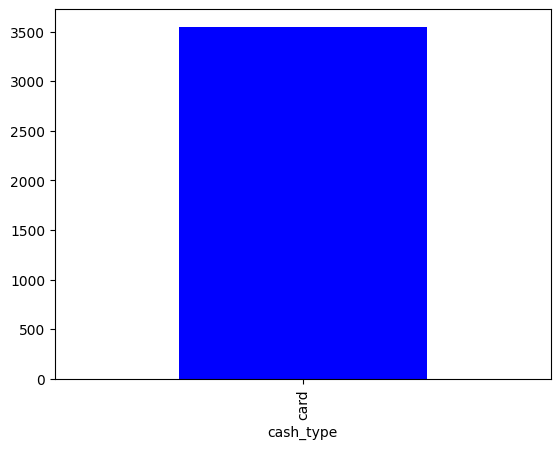

In [23]:
donnees['cash_type'].value_counts().plot(kind='bar', color=['blue', 'orange'])

In [26]:
# 10 Les 10 des transactions les plus cheres ( les plus grands montants de 'money')
classement_top10=donnees.sort_values(by='money', ascending=False).head(10)
classement_top10[['coffee_name', 'money']]
classement_top10

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
142,14,card,38.7,Latte,Afternoon,Mon,Mar,1,3,2024-03-25,14:29:25.343000
145,10,card,38.7,Cocoa,Morning,Tue,Mar,2,3,2024-03-26,10:35:49.679000
146,10,card,38.7,Latte,Morning,Tue,Mar,2,3,2024-03-26,10:36:36.151000
147,10,card,38.7,Latte,Morning,Tue,Mar,2,3,2024-03-26,10:42:30.170000
276,18,card,38.7,Cocoa,Night,Fri,Apr,5,4,2024-04-19,18:23:19.311000
275,13,card,38.7,Cappuccino,Afternoon,Fri,Apr,5,4,2024-04-19,13:59:49.690000
153,15,card,38.7,Latte,Afternoon,Tue,Mar,2,3,2024-03-26,15:48:02.270000
154,18,card,38.7,Latte,Night,Tue,Mar,2,3,2024-03-26,18:33:38.568000
155,18,card,38.7,Hot Chocolate,Night,Tue,Mar,2,3,2024-03-26,18:34:54.648000


In [27]:
classement_top10.to_csv('top10_ventes.csv',index=False)

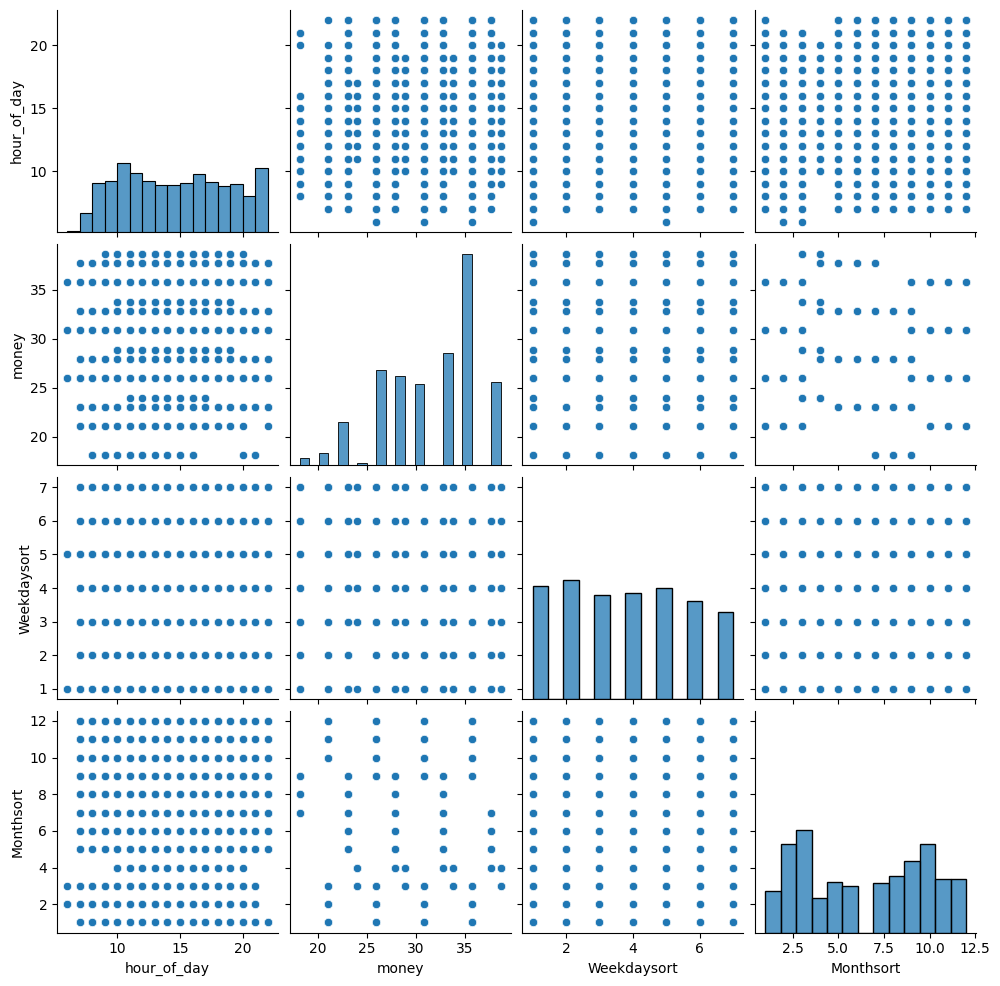

In [28]:
#### visualisation de relation entres toutes les donnees et les distributions
sns.pairplot(donnees)
plt.show()

In [32]:
donnees_numeriques=donnees.select_dtypes(include=[np.number])
donnees_numeriques


,hour_of_day,money,Weekdaysort,Monthsort
0,10,38.70,5,3
1,12,38.70,5,3
2,12,38.70,5,3
3,13,28.90,5,3
4,13,38.70,5,3
...,...,...,...,...
3542,10,35.76,7,3
3543,14,35.76,7,3
3544,14,35.76,7,3
3545,15,25.96,7,3


In [33]:
# Correlation entre les variables numeriques
correlation_matrix = donnees_numeriques.corr()
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

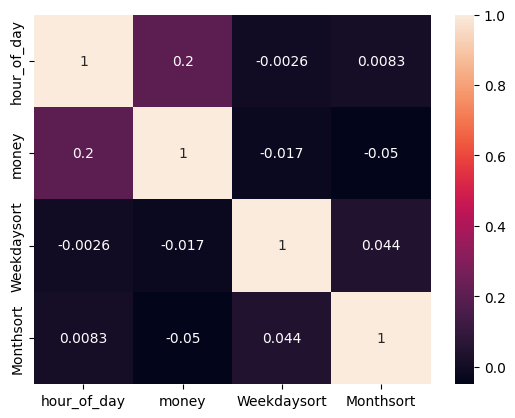

In [37]:
sns.heatmap(donnees_numeriques.corr(), annot=True)
plt.show()

In [38]:
donnees_numeriques.corr()

,hour_of_day,money,Weekdaysort,Monthsort
hour_of_day,1.000000,0.202748,-0.002614,0.008293
money,0.202748,1.000000,-0.017264,-0.050043
Weekdaysort,-0.002614,-0.017264,1.000000,0.044141
Monthsort,0.008293,-0.050043,0.044141,1.000000
